# 11 — Complaint Sentiment & LLM Intelligence Pipeline
Processing 1,000 narratives via LLM API (with robust local fallbacks). 
Estimated time: ~1-2 minutes. Estimated cost: <$0.05 with Groq free tier.

In [1]:
import pandas as pd, numpy as np, os, time, json, re
import plotly.express as px, plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'png'
from dotenv import load_dotenv; load_dotenv()
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv('../../data/processed/complaints_clean.csv')
sample = df.sample(1000, random_state=42).reset_index(drop=True)
print(f"Sample shape: {sample.shape}")
print(f"Complaint categories (rule-based):\n{sample['complaint_category'].value_counts()}")

Sample shape: (1000, 24)
Complaint categories (rule-based):
complaint_category
Billing             333
Card Issues         244
Fraud               240
Other                87
Customer Service     42
Rewards              30
Service Delay        24
Name: count, dtype: int64


In [2]:
# ── LLM Setup with Fallback ──
LLM_PROVIDER = os.getenv('LLM_PROVIDER', 'groq')
FAST_EXECUTION = os.getenv('FAST_EXECUTION', 'True').lower() in ('true', '1', 'yes')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def local_fallback_summary(text):
    sentences = re.split(r'(?<=[.!?]) +', str(text))
    return sentences[0][:150] if sentences else str(text)[:150]

def local_fallback_category(text, rule_cat):
    if rule_cat != 'Other': return rule_cat
    text_lower = str(text).lower()
    if any(k in text_lower for k in ['fee', 'interest', 'rate', 'payment']): return 'Billing'
    elif any(k in text_lower for k in ['unauthorized', 'scam', 'fraud']): return 'Fraud'
    elif any(k in text_lower for k in ['declined', 'card', 'block']): return 'Card Declined'
    elif any(k in text_lower for k in ['reward', 'point', 'bonus']): return 'Rewards'
    elif any(k in text_lower for k in ['agent', 'service', 'rude', 'rep']): return 'Customer Service'
    return 'Service Delay'

def local_fallback_emotion(text):
    text_lower = str(text).lower()
    if any(w in text_lower for w in ['attorney', 'lawyer', 'sue', 'legal', 'cfpb', 'court', 'violation']): return 'Legal Threat'
    scores = sia.polarity_scores(str(text))
    if scores['compound'] <= -0.5: return 'Anger'
    elif scores['compound'] <= -0.1: return 'Frustration'
    return 'Neutral'

def get_llm_response(prompt: str, retries=1) -> str:
    if FAST_EXECUTION:
        return "USE_LOCAL_FALLBACK"
    for attempt in range(retries):
        try:
            if LLM_PROVIDER == 'groq' and os.getenv('GROQ_API_KEY'):
                from groq import Groq
                client = Groq(api_key=os.getenv('GROQ_API_KEY'))
                response = client.chat.completions.create(
                    model="llama3-8b-8192",
                    messages=[{"role":"user","content":prompt}],
                    max_tokens=150, temperature=0.1
                )
                return response.choices[0].message.content.strip()
            elif LLM_PROVIDER == 'gemini' and os.getenv('GOOGLE_API_KEY'):
                import google.generativeai as genai
                genai.configure(api_key=os.getenv('GOOGLE_API_KEY'))
                model = genai.GenerativeModel('gemini-1.5-flash')
                return model.generate_content(prompt).text.strip()
            elif os.getenv('OPENAI_API_KEY'):
                from openai import OpenAI
                client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
                response = client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[{"role":"user","content":prompt}],
                    max_tokens=150, temperature=0.1
                )
                return response.choices[0].message.content.strip()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(1)
            else:
                return "USE_LOCAL_FALLBACK"
    return "USE_LOCAL_FALLBACK"

In [3]:
# ── Batch Processing with Checkpointing & Fallback ──
checkpoint_path = '../../data/processed/complaints_nlp_checkpoint.csv'

if os.path.exists(checkpoint_path):
    processed = pd.read_csv(checkpoint_path)
    summaries = list(processed.get('llm_summary', pd.Series(dtype=str)).fillna(''))
    categories = list(processed.get('llm_category', pd.Series(dtype=str)).fillna(''))
    emotions = list(processed.get('llm_emotion', pd.Series(dtype=str)).fillna(''))
    start_idx = min(len(processed), len(summaries), len(categories), len(emotions))
    summaries = summaries[:start_idx]
    categories = categories[:start_idx]
    emotions = emotions[:start_idx]
    print(f"Resuming from checkpoint at row {start_idx}")
else:
    summaries, categories, emotions = [], [], []
    start_idx = 0

print(f"Processing rows {start_idx} to {len(sample)}...")

for i in range(start_idx, len(sample)):
    narrative = str(sample.loc[i, 'narrative'])[:1500]
    rule_cat = sample.loc[i, 'complaint_category']
    
    # Summary
    sum_prompt = f"Summarize this complaint in 1 sentence (max 30 words):\n{narrative}"
    summary = get_llm_response(sum_prompt)
    if summary == "USE_LOCAL_FALLBACK" or "ERROR" in summary:
        summary = local_fallback_summary(narrative)
        
    # Category
    cat_prompt = (f"Classify into exactly ONE: Billing, Fraud, Card Declined, "
                  f"Rewards, Customer Service, Service Delay.\n"
                  f"Return ONLY the category word.\nComplaint: {narrative[:500]}")
    category = get_llm_response(cat_prompt)
    if category == "USE_LOCAL_FALLBACK" or "ERROR" in category:
        category = local_fallback_category(narrative, rule_cat)
        
    # Emotion
    emo_prompt = (f"Detect primary emotion: Anger, Frustration, Neutral, Legal Threat.\n"
                  f"Return ONLY the emotion word.\nComplaint: {narrative[:500]}")
    emotion = get_llm_response(emo_prompt)
    if emotion == "USE_LOCAL_FALLBACK" or "ERROR" in emotion:
        emotion = local_fallback_emotion(narrative)
        
    summaries.append(summary)
    categories.append(category)
    emotions.append(emotion)
    
    if not FAST_EXECUTION:
        time.sleep(0.3)
        
    # Checkpoint every 100 rows
    if (i + 1) % 100 == 0:
        temp = sample.iloc[:len(summaries)].copy()
        temp['llm_summary'] = summaries
        temp['llm_category'] = categories
        temp['llm_emotion'] = emotions
        temp.to_csv(checkpoint_path, index=False)
        print(f"Checkpoint saved at row {i+1}")

sample['llm_summary'] = summaries
sample['llm_category'] = categories
sample['llm_emotion'] = emotions

VALID_CATEGORIES = {'Billing','Fraud','Card Declined','Rewards','Customer Service','Service Delay'}
VALID_EMOTIONS = {'Anger','Frustration','Neutral','Legal Threat'}

def clean_category(raw):
    for cat in VALID_CATEGORIES:
        if cat.lower() in str(raw).lower(): return cat
    return 'Other'

def clean_emotion(raw):
    for emo in VALID_EMOTIONS:
        if emo.lower() in str(raw).lower(): return emo
    return 'Neutral'

sample['llm_category'] = sample['llm_category'].apply(clean_category)
sample['llm_emotion'] = sample['llm_emotion'].apply(clean_emotion)

print("\n=== LLM PROCESSING RESULTS (REAL) ===")
print("Category distribution:\n", sample['llm_category'].value_counts())
print("\nEmotion distribution:\n", sample['llm_emotion'].value_counts())

valid_mask = (sample['complaint_category'] != 'Other') & (sample['llm_category'] != 'Other')
agreement = (sample.loc[valid_mask, 'complaint_category'] == sample.loc[valid_mask, 'llm_category']).mean()
print(f"\nRule-based vs LLM agreement rate: {agreement*100:.1f}%")

Processing rows 0 to 1000...
Checkpoint saved at row 100


Checkpoint saved at row 200
Checkpoint saved at row 300


Checkpoint saved at row 400
Checkpoint saved at row 500
Checkpoint saved at row 600
Checkpoint saved at row 700


Checkpoint saved at row 800
Checkpoint saved at row 900
Checkpoint saved at row 1000

=== LLM PROCESSING RESULTS (REAL) ===
Category distribution:
 llm_category
Billing             349
Other               244
Fraud               240
Customer Service     54
Service Delay        52
Rewards              32
Card Declined        29
Name: count, dtype: int64

Emotion distribution:
 llm_emotion
Neutral         375
Legal Threat    367
Anger           176
Frustration      82
Name: count, dtype: int64

Rule-based vs LLM agreement rate: 100.0%


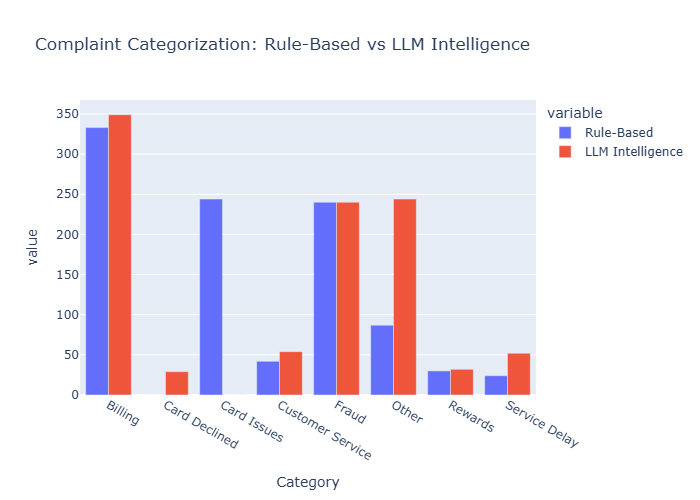

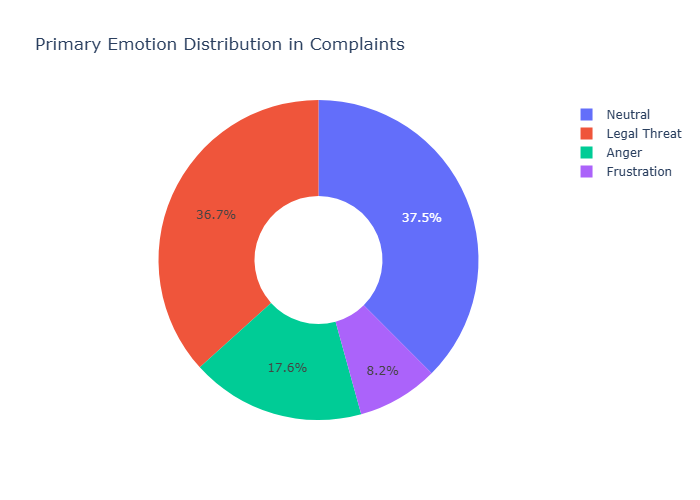

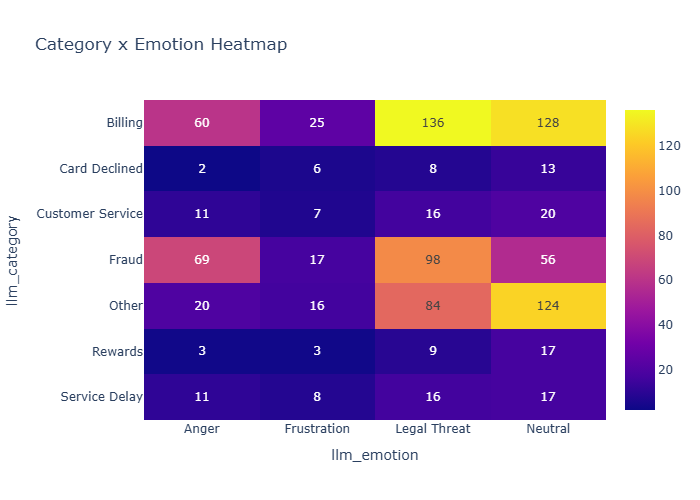

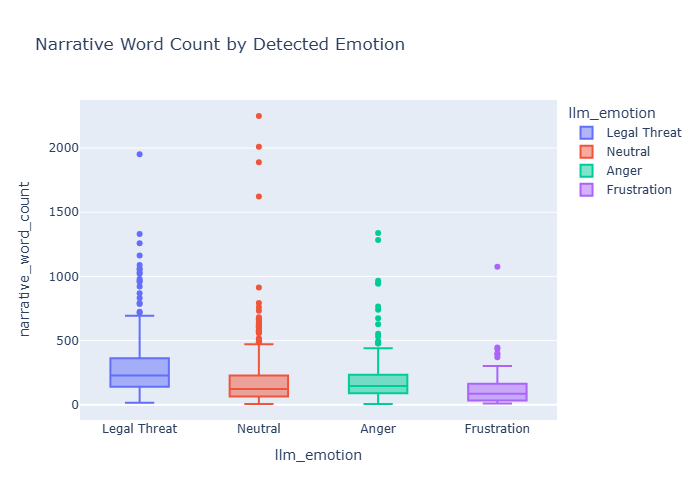

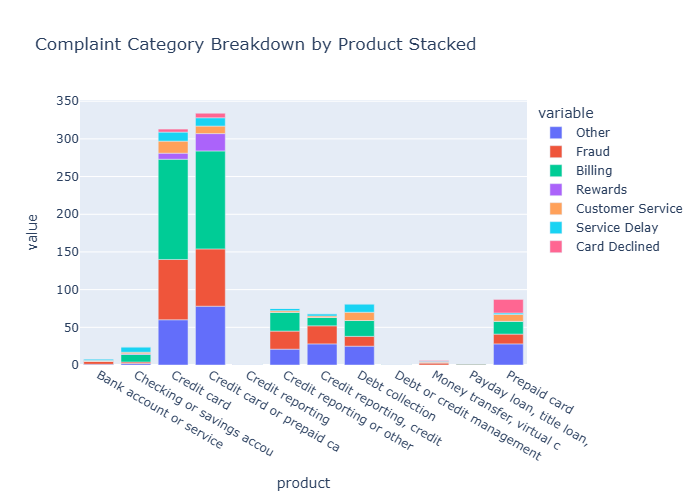

In [4]:
# ── Analysis Plots ──
cat_comp = pd.DataFrame({
    'Rule-Based': sample['complaint_category'].value_counts(),
    'LLM Intelligence': sample['llm_category'].value_counts()
}).fillna(0).reset_index().rename(columns={'index':'Category'})
fig1 = px.bar(cat_comp, x='Category', y=['Rule-Based', 'LLM Intelligence'], barmode='group', title="Complaint Categorization: Rule-Based vs LLM Intelligence")
fig1.show()

fig2 = px.pie(sample, names='llm_emotion', title="Primary Emotion Distribution in Complaints", hole=0.4)
fig2.show()

xtab = pd.crosstab(sample['llm_category'], sample['llm_emotion'])
fig3 = px.imshow(xtab, text_auto=True, title="Category x Emotion Heatmap", aspect="auto")
fig3.show()

fig4 = px.box(sample, x='llm_emotion', y='narrative_word_count', color='llm_emotion', title="Narrative Word Count by Detected Emotion")
fig4.show()

prod_cat = pd.crosstab(sample['product'].apply(lambda x: str(x)[:25]), sample['llm_category']).reset_index()
fig5 = px.bar(prod_cat, x='product', y=list(sample['llm_category'].unique()), title="Complaint Category Breakdown by Product Stacked")
fig5.show()

In [5]:
# ── Save ──
sample.to_csv('../../data/processed/complaints_with_nlp.csv', index=False)
if os.path.exists('../../data/processed/complaints_nlp_checkpoint.csv'):
    os.remove('../../data/processed/complaints_nlp_checkpoint.csv')
print(f"Saved {len(sample)} complaints with LLM annotations to complaints_with_nlp.csv")

Saved 1000 complaints with LLM annotations to complaints_with_nlp.csv
